<a href="https://colab.research.google.com/github/osoliman/DSC110/blob/main/Prediction/DSC110_Prediction_Model_Evaluation_Explanation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Model Evaluation and Explanation**

Model Evaluation

Evaluation of Classification models

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
X_train = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/X_train.csv')
X_test = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/X_test.csv')
y_train = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/y_train.csv')
y_test = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/y_test.csv')

#to prevent warning, converting the y from df to 1d series
y_train = y_train.squeeze()
y_test  = y_test.squeeze()

In [3]:
#Build the model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [8]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
#print(classification_report(y_test, y_pred, labels=[1]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

           0       0.86      0.97      0.91      1289
           1       0.29      0.06      0.11       216

    accuracy                           0.84      1505
   macro avg       0.58      0.52      0.51      1505
weighted avg       0.78      0.84      0.80      1505

AUC-ROC: 0.7488


==============================

ALL THE BELOW IS DEMO

You don't need to comment on it

Changing the threshold

In [ ]:
# Changing threshold to 0.3: classify as positive if prob >= 0.3
y_pred_03 = (y_prob >= 0.3).astype(int)

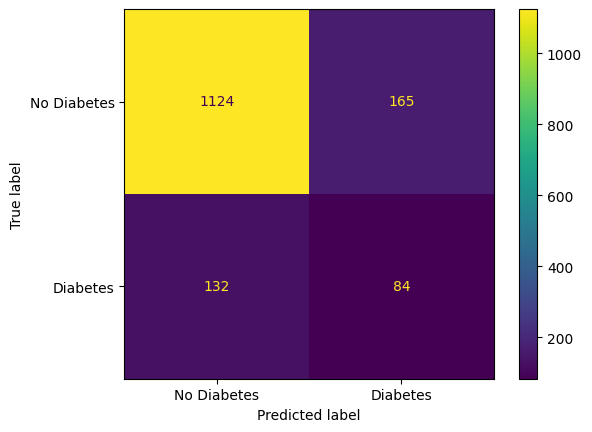

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_03, display_labels=['No Diabetes', 'Diabetes'])
plt.show()

In [ ]:
# Changing threshold to 0.7: classify as positive if prob >= 0.7
y_pred_07 = (y_prob >= 0.7).astype(int)

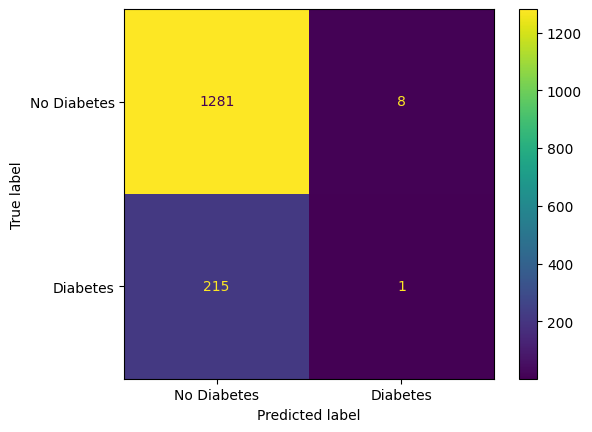

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_07, display_labels=['No Diabetes', 'Diabetes'])
plt.show()

Explainability

Auto ML